In [236]:
!python -m spacy download en_core_web_lg

     ---------------------------------------- 0.0/400.7 MB ? eta -:--:--
     --------------------------------------- 3.1/400.7 MB 26.7 MB/s eta 0:00:15
      ------------------------------------- 10.5/400.7 MB 39.7 MB/s eta 0:00:10
     - ------------------------------------ 17.8/400.7 MB 33.6 MB/s eta 0:00:12
     -- ----------------------------------- 22.8/400.7 MB 30.4 MB/s eta 0:00:13
     -- ----------------------------------- 31.5/400.7 MB 36.6 MB/s eta 0:00:11
     --- ---------------------------------- 41.2/400.7 MB 34.8 MB/s eta 0:00:11
     ---- --------------------------------- 52.4/400.7 MB 37.7 MB/s eta 0:00:10
     ----- -------------------------------- 62.9/400.7 MB 39.7 MB/s eta 0:00:09
     ------ ------------------------------- 73.4/400.7 MB 41.1 MB/s eta 0:00:08
     ------- ------------------------------ 83.9/400.7 MB 42.2 MB/s eta 0:00:08
     -------- ----------------------------- 94.4/400.7 MB 43.0 MB/s eta 0:00:08
     --------- ---------------------------- 94.

In [237]:
from sklearn.feature_extraction.text import CountVectorizer
import glob
import pandas as pd
import nltk
import numpy as np
from nltk import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from nltk import pos_tag
import wordcloud

In [238]:
# modeli za ustrezno obdelavo stavkov, besed, ločil....
nltk.download('punkt')     # stavki, besede
nltk.download('wordnet') #lemmatizacija
nltk.download('averaged_perceptron_tagger') #POS tagganje
nltk.download('omw-1.4') 

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mokro\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\mokro\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\mokro\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\mokro\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [239]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\mokro\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [240]:
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\mokro\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [241]:
# tokenization and lemmatization 
lemmatizer= WordNetLemmatizer()

In [242]:
# pokupčkamo besede s podobnim korenom, pomenom skupaj
# run, runs, running -> run
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('RB'):
        return wordnet.ADV
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    else:
        return wordnet.NOUN

In [248]:
import spacy

nlp = spacy.load("en_core_web_lg")

In [249]:
def tokenize_lematize(tekst):
    doc = nlp(tekst)
    
    izbrane_besede = []
    
    # želimo odstraniti (osebe, kraji, jeziki, narodi)
    odstrani_pos = ['PROPN', 'PRON', 'VERB', 'ADV']
    odstrani_entitete = {'PERSON', 'GPE', 'LOC', 'NORP', 'FAC', 'ORG'}
    
    # ustvarimo množico besed, ki so del prepoznanih entitet (imen)
    

    for token in doc:
        # če je beseda ime
        if token.pos_ in odstrani_pos:
            continue
        if token.ent_type_ in odstrani_entitete:
            continue
            
        # spaCy uporablja oznake: NOUN ADJ
        if token.pos_ in ['NOUN', 'ADJ']:
            beseda = token.lemma_.lower()
            # samo črke in dolžina nad 2 znaka
            if beseda.isalpha() and len(beseda) > 2:
                izbrane_besede.append(beseda)
                
    return izbrane_besede

In [250]:
import random
from sklearn.feature_extraction import text

In [278]:
base_vectorizer = CountVectorizer(stop_words='english')
base_stopwords = base_vectorizer.get_stop_words()


custom_words = {
    # založniški šum 
    'book', 'novel', 'story', 'author', 'literature', 'edition', 'seller', 
    'read', 'reader', 'page', 'chapter', 'write', 'writer', 'publish', 
    'publication', 'review', 'times', 'york', 'print', 'copy', 'best', 
    'original', 'classic', 'introduction', 'note', 'debut', 'thriller',
    'unique', 'fascinating', 'scandal', 'major', 'character', 'cover', 'magazine',
    'self',
    
    # splošni opisi 
    'way', 'thing', 'important', 'practical', 'young', 'boy', 'girl', 
    'human', 'people', 'great', 'good', 'bad', 'true', 'new', 'old',
    'life', 'world', 'everything', 'day', 'time', 'year', 'make',
    'take', 'come', 'think', 'feel', 'know', 'look', 'want', 'large', 'small',
    'man', 'woman', 'literary', 'secret', 'isbn', 
    
    #iz izpisa
    'professional', 'guide', 'experience', 'natural', 'vivid', 'narrative',
    'compelling', 'extraordinary', 'powerful', 'voice', 'mind'
}


all_stopwords = list(base_stopwords.union(custom_words))

In [283]:
# CountVectorizer odstrani 'stopwords' in ustvari nenegativno matriko, na (i, j)-tem mestu
# imamo pojavitev besede i v j-tem dokumentu (glej zapiske na tablici)

#random.seed(42)
# vzamemo 150/200 knjig, ostale bomo potem poskusali uvrstiti med žanre
filepaths = glob.glob(r'C:\Users\mokro\Desktop\diploma\najbolj_popularne\naj_ang_opisi\*.txt')[:250]
#filepaths= random.sample(filepaths, 150)
# min_df=2, max_df=0.9 odstranita redke in pogoste besede, to uniči celoten rezultat
# custom_stopwords = list(text.ENGLISH_STOP_WORDS.union({'book', 'novel', 'story', 'author', 'character',
#                                                   'edition', 'classic', 'bestseller', 'review',
#                                                   'read', 'reader', 'york', 'times', 'new'}))
vectorizer= CountVectorizer(stop_words=all_stopwords, 
                            tokenizer= tokenize_lematize,
                            input = 'filename', 
                            encoding='latin-1', 
                            min_df=3, 
                            max_df=0.50)

In [284]:
X = vectorizer.fit_transform(filepaths) 


c:\Users\mokro\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [285]:
words = vectorizer.get_feature_names_out()
freq = np.asarray(X.sum(axis=0)).flatten()

top_words = [words[i] for i in freq.argsort()[-50:]]
print(top_words)

['city', 'second', 'dead', 'earth', 'unforgettable', 'event', 'job', 'room', 'crime', 'terrifying', 'high', 'killer', 'school', 'end', 'perfect', 'daughter', 'journey', 'modern', 'power', 'masterpiece', 'father', 'century', 'series', 'generation', 'truth', 'beautiful', 'age', 'alternate', 'home', 'evil', 'mother', 'night', 'murder', 'town', 'house', 'heart', 'work', 'war', 'death', 'child', 'adventure', 'sister', 'dark', 'place', 'past', 'tale', 'friend', 'little', 'family', 'love']


In [286]:
print(X)

# malo lepše, prikaz
dense_matrix = X.toarray()
print(dense_matrix)

#še lepše
feature_names = vectorizer.get_feature_names_out()
df = pd.DataFrame(dense_matrix, columns=feature_names)
print(df.head())

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 5142 stored elements and shape (250, 849)>
  Coords	Values
  (0, 283)	1
  (0, 102)	1
  (0, 179)	3
  (0, 374)	2
  (0, 297)	3
  (0, 557)	2
  (0, 342)	1
  (0, 163)	1
  (0, 441)	1
  (0, 16)	1
  (0, 269)	1
  (0, 687)	1
  (0, 123)	1
  (0, 176)	1
  (0, 735)	2
  (0, 666)	1
  (0, 506)	1
  (0, 112)	1
  (0, 370)	1
  (0, 452)	1
  (1, 452)	2
  (1, 848)	1
  (1, 819)	1
  (1, 648)	1
  (1, 87)	1
  :	:
  (248, 571)	1
  (248, 724)	1
  (249, 557)	1
  (249, 12)	1
  (249, 323)	1
  (249, 434)	2
  (249, 327)	1
  (249, 37)	1
  (249, 691)	1
  (249, 337)	1
  (249, 31)	1
  (249, 518)	1
  (249, 837)	1
  (249, 839)	1
  (249, 782)	1
  (249, 246)	1
  (249, 308)	1
  (249, 838)	1
  (249, 42)	1
  (249, 385)	1
  (249, 597)	2
  (249, 442)	1
  (249, 68)	1
  (249, 59)	1
  (249, 511)	1
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 0 0]
 ...
 [1 0 2 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
   able  absolute  academy  accident  acclaimed  account  achie

In [287]:
def nmf(X, k, max_iter=500, tol=1e-4, random_state=42):
    """
    Nenegativna matrična faktorizacija, ki uporablja pravila za posodobitev elementov na podlagi množenja.

    Parametri:
    -----------
    X : ndarray (m x n)
        Nenegativna matrika
    k : int
        Stevilo komponent (teme/ žanri)
    max_iter : int
        Maksimalno število iteracij
    tol : float
        Toleranca konvergence (izračunano s pomočjo reconstruction error)
    random_state : int
        

    Vrne:
    --------
    W : ndarray (m x k)
    H : ndarray (k x n)
    errors : list
        Reconstruction za vsako iteracijo
    """
    
    np.random.seed(random_state)
    
    m, n = X.shape
    
    #zacnemo z nakljucnimi nenegativnimi vrednostmi
    W = np.random.rand(m, k)
    H = np.random.rand(k, n)
    
    eps = 1e-9
    errors = []
    
    for i in range(max_iter):
        
        # posodabljanje H
        H *= (W.T @ X) / (W.T @ W @ H + eps) # + eps, da ne delimo z 0
        # posodabljanje W
        W *= (X @ H.T) / (W @ (H @ H.T) + eps)
        
        # reconstruction error
        error = np.linalg.norm(X - W @ H, 'fro')
        errors.append(error)
        
        # konvergenca
        if i > 0 and abs(errors[-2] - error) < tol:
            break

    return W, H, errors

In [290]:
# test 

W, H, errors = nmf(X, 5)
print(errors)
#print(W)
#print(H)

[np.float64(84.4808261305519), np.float64(83.60713596913138), np.float64(82.88089066420702), np.float64(82.27496869569984), np.float64(81.79869050237536), np.float64(81.42368859265035), np.float64(81.10970995521863), np.float64(80.8443964856782), np.float64(80.62621924433957), np.float64(80.45249332890205), np.float64(80.32163429355171), np.float64(80.22980572943392), np.float64(80.1653094994858), np.float64(80.11797283632079), np.float64(80.08246834467103), np.float64(80.05551944741264), np.float64(80.03494431450099), np.float64(80.0187410228559), np.float64(80.00528362316987), np.float64(79.99439486405053), np.float64(79.98549733001948), np.float64(79.97835102587831), np.float64(79.97257660299474), np.float64(79.96775385773633), np.float64(79.96363251440366), np.float64(79.95998494041939), np.float64(79.95691173428848), np.float64(79.9541136681921), np.float64(79.95137932622005), np.float64(79.94907016545126), np.float64(79.94700095065146), np.float64(79.94513105164728), np.float64(7

In [291]:
feature_names = vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(H):
    top_words = [feature_names[i] for i in topic.argsort()[-15:]]
    print(f"Tema {topic_idx+1}: {' '.join(top_words)}")

Tema 1: father dangerous work apartment series truth evil night horror tale place friend adventure past dark
Tema 2: century real frozen enemy harsh cold killer plot conflict game death child land family sister
Tema 3: island weekend sun sea half red dead bear big stranger room guest rhyme murder little
Tema 4: black ready college beginning happy home money baby big farm little wood family town house
Tema 5: word beloved alternate plan king son blood strigoi vampire art war room friend heart love


ValueError: num must be an integer with 1 <= num <= 4, not 5

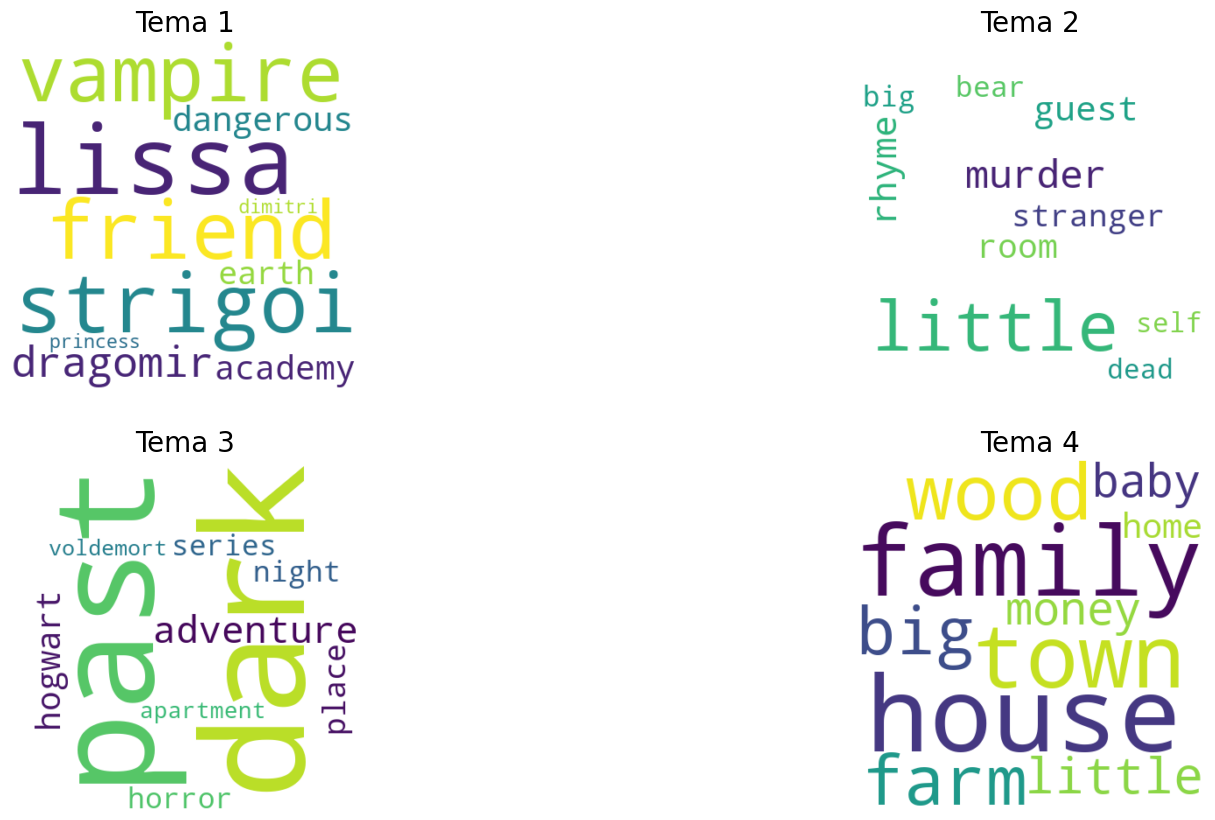

In [225]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

def prikazi_wordclouds(H, feature_names, n_top_words=10):
    n_topics = H.shape[0]
    
    
    plt.figure(figsize=(20, 10))
    
    for topic_idx, topic in enumerate(H):
        # slovar {beseda: utež} za WordCloud
        # top n besed za vsako temo
        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
        topic_words = {feature_names[i]: topic[i] for i in top_features_ind}
        
        
        wc = WordCloud(width=400, height=400, background_color='white', 
                       colormap='viridis', max_words=n_top_words)
        wc.generate_from_frequencies(topic_words)
    
        plt.subplot(2, 2, topic_idx + 1)
        plt.imshow(wc, interpolation='bilinear')
        plt.title(f"Tema {topic_idx + 1}", fontsize=20)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

feature_names = vectorizer.get_feature_names_out()
prikazi_wordclouds(H, feature_names)

In [ ]:
import pandas as pd

# Matrika W nam pove, kateri temi pripada katera knjiga
# Dobimo indeks najvišje vrednosti v vsaki vrstici
dominant_topics = np.argmax(W, axis=1) + 1 # +1 da začnemo s Tema 1

# Pripravimo seznam imen datotek (brez celotne poti, samo ime)
import os
filenames = [os.path.basename(f) for f in filepaths]

# Ustvarimo tabelo
df_results = pd.DataFrame({
    'Knjiga': filenames,
    'Dominantna Tema': dominant_topics
})

# Izpišemo prvih 10 rezultatov
print(df_results.head(50))

# Če želiš preveriti specifično temo (npr. vse knjige v Temi 2):
print(df_results[df_results['Dominantna Tema'] == 3])

          Knjiga  Dominantna Tema
0     opis_1.txt                2
1    opis_10.txt                5
2   opis_100.txt                1
3   opis_101.txt                2
4   opis_102.txt                2
5   opis_103.txt                4
6   opis_104.txt                2
7   opis_105.txt                4
8   opis_106.txt                4
9   opis_107.txt                1
10  opis_108.txt                1
11  opis_109.txt                2
12   opis_11.txt                5
13  opis_110.txt                4
14  opis_111.txt                5
15  opis_112.txt                4
16  opis_113.txt                2
17  opis_114.txt                6
18  opis_115.txt                1
19  opis_116.txt                5
20  opis_117.txt                2
21  opis_118.txt                2
22  opis_119.txt                2
23   opis_12.txt                5
24  opis_120.txt                1
25  opis_121.txt                4
26  opis_122.txt                1
27  opis_123.txt                1
28  opis_124.t